<a href="https://colab.research.google.com/github/HenryZumaeta/py4dl_EPC2026/blob/main/C02_Scrip01_IntroKeras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# El modulo Keras

Diseño se centra en :
* Usabilidad
* Modularidad
* Extensibilidad

## Arquitectura de Keras
- Modelos en Keras
    * API Secuencial
        - Redes FeedForward Estandar
        - Redes Convolucionales simple
        - Redes Recurrentes Unidireccionales
        - Autoencoders (Basicos)
        - Clasificacion/Regresion
    * API Funcional
- Capas (Layers)
    * Dense
    * Conv2D
    * LSTM/GRU
    * Dropout
    * BatchNormalization
- Compilacion
    * Optimizador
    * Funcion de Perdida
    * Metricas
- Entrenamiento

In [ ]:
# Version python
!python --version

Python 3.12.13


In [ ]:
# Version de keras
import keras
keras.__version__


'3.13.2'

In [ ]:
# Version de tensorflow
import tensorflow
tensorflow.__version__

'2.20.0'

# Ejemplo1

In [ ]:
# modulos
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Redes Neuronales: Keras
from  keras.models import Sequential
from keras.layers import Dense

# Descargamos el dataset de kaggle
!kaggle datasets download robintux/salud-mental-agotamiento-estudiantil

# Descomprimirlo
!unzip salud-mental-agotamiento-estudiantil.zip

# Cargar en memoria
df = pd.read_csv("Salud_mental_agotamiento_estudiantil.csv")
df = df.drop("Unnamed: 0", axis = 1)
df.info()

Dataset URL: https://www.kaggle.com/datasets/robintux/salud-mental-agotamiento-estudiantil
License(s): apache-2.0
100% 130M/130M [00:00<00:00, 216MB/s]

Archive:  salud-mental-agotamiento-estudiantil.zip
  inflating: Salud_mental_agotamiento_estudiantil.csv  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 17 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   study_hours_per_day   1000000 non-null  float64
 2   exam_pressure         1000000 non-null  float64
 3   academic_performance  1000000 non-null  float64
 4   stress_level          1000000 non-null  float64
 5   anxiety_score         1000000 non-null  float64
 6   depression_score      1000000 non-null  float64
 7   sleep_hours           1000000 non-null  float64
 8   physical_activity     1000000 non-null  float64
 9   social_support        1000000 non-null  

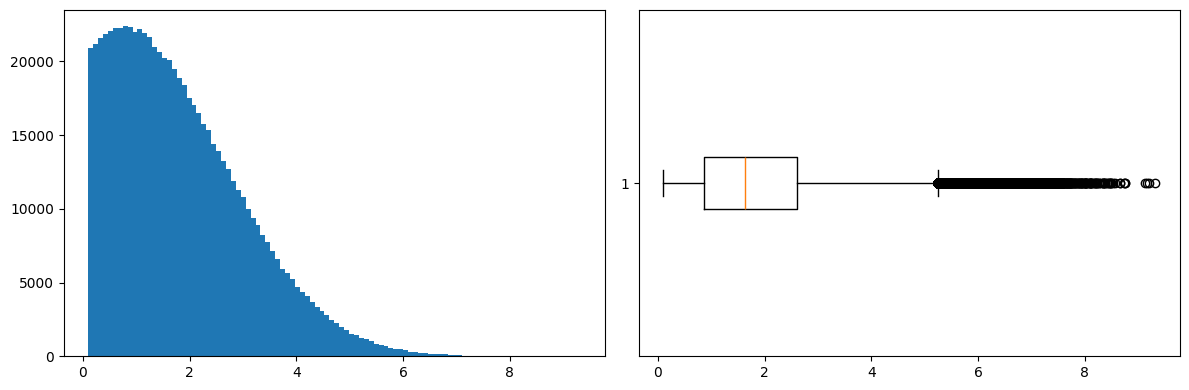

In [ ]:
# Analicemos a la variable dependiente : dropout_risk
y = df.dropout_risk

# Veamos un histograma y un boxplot
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

# Definir una copia de la variable dependiente
# var_y = y.copy()
# var_y = y[y == 0]
var_y = y[y > 0.1]

axes[0].hist(var_y, bins = 100)
axes[1].boxplot(var_y, vert = False)

plt.tight_layout()
plt.show()

In [ ]:
# Para estos valores deberia de realizar otro analisis
y[y == 0].shape

(262338,)

In [ ]:
y.min(), y.max()

(0.0, 9.326226207334855)

In [ ]:
# Vamos a hacer la siguiente consideracion
# Vamos a considerar los valores de la variable dependiente mayores o iguales a 0.01
df = df[df.dropout_risk >= 0.1].reset_index(drop = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 715685 entries, 0 to 715684
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   age                   715685 non-null  int64  
 1   study_hours_per_day   715685 non-null  float64
 2   exam_pressure         715685 non-null  float64
 3   academic_performance  715685 non-null  float64
 4   stress_level          715685 non-null  float64
 5   anxiety_score         715685 non-null  float64
 6   depression_score      715685 non-null  float64
 7   sleep_hours           715685 non-null  float64
 8   physical_activity     715685 non-null  float64
 9   social_support        715685 non-null  float64
 10  screen_time           715685 non-null  float64
 11  internet_usage        715685 non-null  float64
 12  financial_stress      715685 non-null  float64
 13  family_expectation    715685 non-null  float64
 14  burnout_score         715685 non-null  float64
 15  

In [ ]:
# Estrategia : Seleccionar una muestra de los datos (10% del total)
# Esto para acortar el tiempo de procesamiento
df = df.sample(frac= 0.1).reset_index(drop = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71568 entries, 0 to 71567
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   71568 non-null  int64  
 1   study_hours_per_day   71568 non-null  float64
 2   exam_pressure         71568 non-null  float64
 3   academic_performance  71568 non-null  float64
 4   stress_level          71568 non-null  float64
 5   anxiety_score         71568 non-null  float64
 6   depression_score      71568 non-null  float64
 7   sleep_hours           71568 non-null  float64
 8   physical_activity     71568 non-null  float64
 9   social_support        71568 non-null  float64
 10  screen_time           71568 non-null  float64
 11  internet_usage        71568 non-null  float64
 12  financial_stress      71568 non-null  float64
 13  family_expectation    71568 non-null  float64
 14  burnout_score         71568 non-null  float64
 15  mental_health_index

In [ ]:
# Definamos las variables a considerar en el modelo
# X : Variables independientes
# y : Variable Dependiente
X = df.iloc[:, :-1]
y = df.dropout_risk

# Ahora particionamos el dataset :
    # Subconjunto de entrenamiento
    # subconjunto de testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25)
print(f" Numero de Observaciones train : {X_train.shape[0]:d}")
print(f" Numero de Observaciones test : {X_test.shape[0]:d}")

 Numero de Observaciones train : 53676
 Numero de Observaciones test : 17892


In [ ]:
X.describe()

,age,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index
count,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000,71568.000000
mean,23.018514,5.165310,6.173933,71.076288,4.672721,3.296139,1.603899,6.375157,2.966930,4.614092,5.008884,5.035762,5.401804,6.095875,2.256002,6.660900
std,3.731917,1.985714,1.539156,5.667886,1.603697,1.478204,1.240712,1.470900,1.465148,1.894006,1.954689,2.152311,1.895161,1.950083,1.684126,1.262320
min,17.000000,0.000000,1.000000,46.880256,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.505552
25%,20.000000,3.819113,5.132424,67.243992,3.607399,2.278898,0.554993,5.369093,1.943837,3.323401,3.641584,3.496849,4.121164,4.765353,0.879283,5.823389
50%,23.000000,5.172155,6.184534,71.068793,4.687222,3.299293,1.505961,6.372331,2.953046,4.610198,4.994021,4.998429,5.398996,6.117968,2.131284,6.679566
75%,26.000000,6.502075,7.215560,74.903349,5.756543,4.301951,2.440975,7.384557,3.967269,5.900538,6.346243,6.502268,6.692457,7.471048,3.377254,7.529572
max,29.000000,13.676074,10.000000,94.948963,10.000000,9.108828,7.082334,10.000000,7.000000,10.000000,12.000000,14.000000,10.000000,10.000000,10.000000,10.000000


## Primera Red Neuronal

In [ ]:
# Instanciamos la clase Sequential
ModelBase = Sequential()

# Agregamos capas ocultas
# La primera capa oculta posee la informacion de la capa de entrada, es
# decir de las variables independientes
ModelBase.add(Dense(
    units = 10,
    activation = "relu",
    input_dim = X.shape[1],
    name = "Primera_capa_oculta"
))

# Agreguemos 7 capas ocultas
ModelBase.add(Dense(
    units = 16,
    activation = "elu",
    name = "Segunda_capa_oculta"
))

ModelBase.add(Dense(
    units = 24,
    activation = "selu",
    name = "Tercera_capa_oculta"
))

ModelBase.add(Dense(
    units = 15,
    activation = "relu",
    name = "Cuarta_capa_oculta"
))

ModelBase.add(Dense(
    units = 14,
    activation = "tanh",
    name = "Quinta_capa_oculta"
))

ModelBase.add(Dense(
    units = 15,
    activation = "relu",
    name = "Sexta_capa_oculta"
))

ModelBase.add(Dense(
    units = 5,
    activation = "sigmoid",
    name = "Septima_capa_oculta"
))

ModelBase.add(Dense(
    units = 3,
    activation = "elu",
    name = "octava_capa_oculta"
))

# Capa de Salida
ModelBase.add(Dense(
    units  = 1 ,
    activation = "relu",
    name = "Capa_de_Salida"
))





/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ModelBase

<Sequential name=sequential, built=True>

In [ ]:
ModelBase.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Primera_capa_oculta (Dense)     │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Segunda_capa_oculta (Dense)     │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Tercera_capa_oculta (Dense)     │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Cuarta_capa_oculta (Dense)      │ (None, 15)             │           375 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Quinta_capa_oculta (Dense)      │ (None, 14)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sexta_capa_oculta (Dense)       │ (None, 15)             │           225 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Septima_capa_oculta (Dense)     │ (None, 5)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ octava_capa_oculta (Dense)      │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_de_Salida (Dense)          │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,680 (6.56 KB)

 Trainable params: 1,680 (6.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilacion del modelo
ModelBase.compile(
    loss = "mean_absolute_error",
    optimizer = "adam",
    metrics = ["mean_absolute_percentage_error"]
)

In [ ]:
ModelBase.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Primera_capa_oculta (Dense)     │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Segunda_capa_oculta (Dense)     │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Tercera_capa_oculta (Dense)     │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Cuarta_capa_oculta (Dense)      │ (None, 15)             │           375 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Quinta_capa_oculta (Dense)      │ (None, 14)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sexta_capa_oculta (Dense)       │ (None, 15)             │           225 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Septima_capa_oculta (Dense)     │ (None, 5)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ octava_capa_oculta (Dense)      │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_de_Salida (Dense)          │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,680 (6.56 KB)

 Trainable params: 1,680 (6.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Procedimiento de Ajuste
HistoriaAjusteModelBase = ModelBase.fit(X_train, y_train, epochs = 10)

# MOraleja : A mas epocas , le das mayor probabilidad de encontrar mejores pesos
# Probar con 50, 100, 200 y 500 epocas

Epoch 1/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6669 - mean_absolute_percentage_error: 72.6850
Epoch 2/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.6669 - mean_absolute_percentage_error: 72.4226
Epoch 3/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.6669 - mean_absolute_percentage_error: 72.7301
Epoch 4/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.6657 - mean_absolute_percentage_error: 72.6253
Epoch 5/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.6669 - mean_absolute_percentage_error: 72.6533
Epoch 6/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.6653 - mean_absolute_percentage_error: 72.4431
Epoch 7/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.6670 - mean_absolute_percentage_error: 72.4011
Epoch 8/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.6655 - mean_absolute_percentage_error: 72.5593
Epoch 9/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.6655 - mean_absolute_percentage_error: 72.3049
E

In [ ]:
# Suponiendo que en entrenamiento logramos "buenos resultados", entonces necesitamos
# utilizar el modelo con datos que no ha visto en entrenamiento
y_forecast_base = ModelBase.predict(X_test)

560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
# Indicador de calidad
mape1_base = metrics.mean_absolute_percentage_error(y_test, y_forecast_base)
mape1_base

0.7544323432408043

In [ ]:
# Las funciones de activacion se encuentran disponibles en el submodulo activations
dir(keras.activations)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparse_sigmoid',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']

In [ ]:
# Documentacion de relu
help(keras.activations.relu)

Help on function relu in module keras.src.activations.activations:

relu(x, negative_slope=0.0, max_value=None, threshold=0.0)
    Applies the rectified linear unit activation function.

    With default values, this returns the standard ReLU activation:
    `max(x, 0)`, the element-wise maximum of 0 and the input tensor.

    Modifying default parameters allows you to use non-zero thresholds,
    change the max value of the activation,
    and to use a non-zero multiple of the input for values below the threshold.

    Examples:

    >>> x = [-10, -5, 0.0, 5, 10]
    >>> keras.activations.relu(x)
    [ 0.,  0.,  0.,  5., 10.]
    >>> keras.activations.relu(x, negative_slope=0.5)
    [-5. , -2.5,  0. ,  5. , 10. ]
    >>> keras.activations.relu(x, max_value=5.)
    [0., 0., 0., 5., 5.]
    >>> keras.activations.relu(x, threshold=5.)
    [-0., -0.,  0.,  0., 10.]

    Args:
        x: Input tensor.
        negative_slope: A `float` that controls the slope
            for values lower th

In [ ]:
# A la primera arquitectura cambiemosle la funcion de activacion de la capa de salida
# Instanciamos la clase Sequential
ModelBase = Sequential()

# Agregamos capas ocultas
# La primera capa oculta posee la informacion de la capa de entrada, es
# decir de las variables independientes
ModelBase.add(Dense(
    units = 10,
    activation = "relu",
    input_dim = X.shape[1],
    name = "Primera_capa_oculta"
))

# Agreguemos 7 capas ocultas
ModelBase.add(Dense(
    units = 16,
    activation = "elu",
    name = "Segunda_capa_oculta"
))

ModelBase.add(Dense(
    units = 24,
    activation = "selu",
    name = "Tercera_capa_oculta"
))

ModelBase.add(Dense(
    units = 15,
    activation = "relu",
    name = "Cuarta_capa_oculta"
))

ModelBase.add(Dense(
    units = 14,
    activation = "tanh",
    name = "Quinta_capa_oculta"
))

ModelBase.add(Dense(
    units = 15,
    activation = "relu",
    name = "Sexta_capa_oculta"
))

ModelBase.add(Dense(
    units = 5,
    activation = "relu",
    name = "Septima_capa_oculta"
))

ModelBase.add(Dense(
    units = 3,
    activation = "exponential",
    name = "octava_capa_oculta"
))

# Capa de Salida
ModelBase.add(Dense(
    units  = 1 ,
    activation = "linear",
    name = "Capa_de_Salida"
))

# Compilamos el modelo
ModelBase.compile(
    loss = "mean_absolute_error",
    optimizer = "adam",
    metrics = ["mean_absolute_percentage_error"]
)

# Procedimiento de ajuste
HistoriaAjusteModelBase2 = ModelBase.fit(X_train, y_train,
                                         epochs = 10,
                                         batch_size = 128)


# Calculamos pronosticos
y_forecast_base2 = ModelBase.predict(X_test)

# Indicador de calidad
mape2_base = metrics.mean_absolute_percentage_error(y_test, y_forecast_base2)
mape2_base




Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.8195 - mean_absolute_percentage_error: 82.4871
Epoch 2/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6792 - mean_absolute_percentage_error: 74.5267
Epoch 3/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6720 - mean_absolute_percentage_error: 73.5545
Epoch 4/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6672 - mean_absolute_percentage_error: 72.8208
Epoch 5/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6675 - mean_absolute_percentage_error: 72.9842
Epoch 6/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6666 - mean_absolute_percentage_error: 72.9169
Epoch 7/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6658 - mean_absolute_percentage_error: 72.4749
Epoch 8/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6654 - mean_absolute_percentage_error: 72.8057
Epoch 9/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6670 - mean_absolute_percentage_error: 72.8029
Epoch 10/10
420/420 ━━━━━━━━━━

0.7308141138096683

In [ ]:
# Experimentos
# Ajustar nuevamente la arquitectura base en epochs = 50,100,200,500 y 1000
# MOdificar el numero de neuronas de cada capa oculta (tambien las funciones de activacion)